In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms

import numpy as np
from PIL import Image
import os
import json
import random
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías cargadas")
print(f"🖥️  Dispositivo: {device}")

✅ Librerías cargadas
🖥️  Dispositivo: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/trazos'

# ── Rutas en Drive (origen) ────────────────────────────
F1_BASICA_DRIVE    = os.path.join(BASE, 'dataset', 'fase1_entrenamiento', 'geometria_basica')
F1_RUIDO_DRIVE     = os.path.join(BASE, 'dataset', 'fase1_entrenamiento', 'ruido')
F2_COMPLEJA_DRIVE  = os.path.join(BASE, 'dataset', 'fase2_entrenamiento', 'geometria_compleja')
F2_RUIDO_DRIVE     = os.path.join(BASE, 'dataset', 'fase2_entrenamiento', 'ruido_complejo')
F3_TUBERIAS_DRIVE  = os.path.join(BASE, 'dataset', 'fase3_entrenamiento', 'tuberias_sinteticas')
F3_RUIDO_DRIVE     = os.path.join(BASE, 'dataset', 'fase3_entrenamiento', 'tuberias_con_ruido')

PATH_MODELOS = os.path.join(BASE, 'modelos', 'fase3')
PATH_LOGS    = os.path.join(BASE, 'logs')

# ── Verificar rutas Drive ──────────────────────────────
rutas = [F1_BASICA_DRIVE, F1_RUIDO_DRIVE,
         F2_COMPLEJA_DRIVE, F2_RUIDO_DRIVE,
         F3_TUBERIAS_DRIVE, F3_RUIDO_DRIVE,
         PATH_MODELOS, PATH_LOGS]

for r in rutas:
    estado = "✅" if os.path.exists(r) else "❌ NO EXISTE"
    print(f"{estado} — {r}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/geometria_basica
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/ruido
✅ — /content/drive/MyDrive/trazos/dataset/fase2_entrenamiento/geometria_compleja
✅ — /content/drive/MyDrive/trazos/dataset/fase2_entrenamiento/ruido_complejo
✅ — /content/drive/MyDrive/trazos/dataset/fase3_entrenamiento/tuberias_sinteticas
✅ — /content/drive/MyDrive/trazos/dataset/fase3_entrenamiento/tuberias_con_ruido
✅ — /content/drive/MyDrive/trazos/modelos/fase3
✅ — /content/drive/MyDrive/trazos/logs


In [3]:
LOCAL = '/content/dataset_local'

datasets_a_copiar = [
    ('fase1/geometria_basica',    F1_BASICA_DRIVE),
    ('fase1/ruido',               F1_RUIDO_DRIVE),
    ('fase2/geometria_compleja',  F2_COMPLEJA_DRIVE),
    ('fase2/ruido_complejo',      F2_RUIDO_DRIVE),
    ('fase3/tuberias_sinteticas', F3_TUBERIAS_DRIVE),
    ('fase3/tuberias_con_ruido',  F3_RUIDO_DRIVE),
]

print("📦 Copiando dataset a RAM local...")
print("   Tarda ~3-5 min pero acelera x10 el entrenamiento")
print()

for nombre, origen in datasets_a_copiar:
    destino = os.path.join(LOCAL, nombre)
    if os.path.exists(destino):
        n = sum(len(f) for _, _, f in os.walk(destino))
        print(f"   ✅ Ya existe local: {nombre} ({n} archivos)")
        continue
    print(f"   📁 Copiando: {nombre} ...", end=' ')
    shutil.copytree(origen, destino)
    n = sum(len(f) for _, _, f in os.walk(destino))
    print(f"✅ ({n} archivos)")

print()

# ── Rutas locales (las que usará el entrenamiento) ─────
F1_BASICA   = os.path.join(LOCAL, 'fase1/geometria_basica')
F1_RUIDO    = os.path.join(LOCAL, 'fase1/ruido')
F2_COMPLEJA = os.path.join(LOCAL, 'fase2/geometria_compleja')
F2_RUIDO    = os.path.join(LOCAL, 'fase2/ruido_complejo')
F3_TUBERIAS = os.path.join(LOCAL, 'fase3/tuberias_sinteticas')
F3_RUIDO    = os.path.join(LOCAL, 'fase3/tuberias_con_ruido')

print("✅ Dataset en RAM local")
print("🔁 Rutas actualizadas — entrenamiento leerá desde RAM")

📦 Copiando dataset a RAM local...
   Tarda ~3-5 min pero acelera x10 el entrenamiento

   ✅ Ya existe local: fase1/geometria_basica (2800 archivos)
   ✅ Ya existe local: fase1/ruido (2800 archivos)
   ✅ Ya existe local: fase2/geometria_compleja (2800 archivos)
   ✅ Ya existe local: fase2/ruido_complejo (2800 archivos)
   ✅ Ya existe local: fase3/tuberias_sinteticas (2800 archivos)
   ✅ Ya existe local: fase3/tuberias_con_ruido (2800 archivos)

✅ Dataset en RAM local
🔁 Rutas actualizadas — entrenamiento leerá desde RAM


In [4]:
class TrazosDataset(Dataset):
    def __init__(self, fase_dir, split, img_size=256):
        self.dir_input = os.path.join(fase_dir, split, 'inputs')
        self.dir_mask  = os.path.join(fase_dir, split, 'masks')
        self.img_size  = img_size
        self.archivos  = sorted(os.listdir(self.dir_input))

        self.transform_img = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])
        self.transform_mask = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        nombre = self.archivos[idx]
        img  = Image.open(os.path.join(self.dir_input, nombre)).convert('RGB')
        mask = Image.open(os.path.join(self.dir_mask,  nombre)).convert('L')
        return self.transform_img(img), self.transform_mask(mask)


# ── Train: F1 + F2 + F3 ───────────────────────────────
train_dataset = ConcatDataset([
    TrazosDataset(F1_BASICA,   'train'),
    TrazosDataset(F1_RUIDO,    'train'),
    TrazosDataset(F2_COMPLEJA, 'train'),
    TrazosDataset(F2_RUIDO,    'train'),
    TrazosDataset(F3_TUBERIAS, 'train'),
    TrazosDataset(F3_RUIDO,    'train'),
])

# ── Val ────────────────────────────────────────────────
val_dataset = ConcatDataset([
    TrazosDataset(F1_BASICA,   'val'),
    TrazosDataset(F1_RUIDO,    'val'),
    TrazosDataset(F2_COMPLEJA, 'val'),
    TrazosDataset(F2_RUIDO,    'val'),
    TrazosDataset(F3_TUBERIAS, 'val'),
    TrazosDataset(F3_RUIDO,    'val'),
])

# ── Test por separado ──────────────────────────────────
test_f1_basica   = TrazosDataset(F1_BASICA,   'test')
test_f1_ruido    = TrazosDataset(F1_RUIDO,    'test')
test_f2_compleja = TrazosDataset(F2_COMPLEJA, 'test')
test_f2_ruido    = TrazosDataset(F2_RUIDO,    'test')
test_f3_tuberias = TrazosDataset(F3_TUBERIAS, 'test')
test_f3_ruido    = TrazosDataset(F3_RUIDO,    'test')

test_dataset = ConcatDataset([
    test_f1_basica, test_f1_ruido,
    test_f2_compleja, test_f2_ruido,
    test_f3_tuberias, test_f3_ruido
])

print(f"✅ Dataset acumulativo F1+F2+F3 cargado")
print(f"   Train : {len(train_dataset):>5} imágenes")
print(f"   Val   : {len(val_dataset):>5} imágenes")
print(f"   Test  : {len(test_dataset):>5} imágenes")
print(f"   Total : {len(train_dataset)+len(val_dataset)+len(test_dataset):>5} imágenes")

✅ Dataset acumulativo F1+F2+F3 cargado
   Train :  6000 imágenes
   Val   :  1200 imágenes
   Test  :  1200 imágenes
   Total :  8400 imágenes


In [5]:
BATCH_SIZE  = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True)   # pin_memory acelera transferencia a GPU
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f"✅ DataLoaders listos")
print(f"   Batches train : {len(train_loader)}")
print(f"   Batches val   : {len(val_loader)}")
print(f"   Batches test  : {len(test_loader)}")
print(f"   NUM_WORKERS   : {NUM_WORKERS}")
print(f"   pin_memory    : True")

✅ DataLoaders listos
   Batches train : 375
   Batches val   : 75
   Batches test  : 75
   NUM_WORKERS   : 2
   pin_memory    : True


In [6]:
V1_TEST_IOU  = 0.5833
V1_TEST_DICE = 0.7363
V2_TEST_IOU  = 0.9299
V2_TEST_DICE = 0.9635
V3_TEST_IOU  = 0.9329
V3_TEST_DICE = 0.9651
BASELINE_IOU = 0.0555

print("=" * 58)
print("📊 HISTORIAL DE VERSIONES")
print("=" * 58)
print(f"{'Versión':<22} {'IoU':>10} {'Dice':>10} {'Dataset':>10}")
print("-" * 58)
print(f"{'Baseline Canny':<22} {BASELINE_IOU:>10.4f} {'—':>10} {'—':>10}")
print(f"{'v1 CNN':<22} {V1_TEST_IOU:>10.4f} {V1_TEST_DICE:>10.4f} {'F1':>10}")
print(f"{'v2 U-Net':<22} {V2_TEST_IOU:>10.4f} {V2_TEST_DICE:>10.4f} {'F1':>10}")
print(f"{'v3 U-Net acum.':<22} {V3_TEST_IOU:>10.4f} {V3_TEST_DICE:>10.4f} {'F1+F2':>10}")
print(f"{'v4 objetivo':<22} {'> 0.88':>10} {'> 0.93':>10} {'F1+F2+F3':>10}")
print("=" * 58)
print()
print("   ⚠️  F3 tuberías es el dataset más difícil")
print("   El IoU global puede bajar levemente vs v3")
print("   Lo crítico es el IoU específico de F3")

📊 HISTORIAL DE VERSIONES
Versión                       IoU       Dice    Dataset
----------------------------------------------------------
Baseline Canny             0.0555          —          —
v1 CNN                     0.5833     0.7363         F1
v2 U-Net                   0.9299     0.9635         F1
v3 U-Net acum.             0.9329     0.9651      F1+F2
v4 objetivo                > 0.88     > 0.93   F1+F2+F3

   ⚠️  F3 tuberías es el dataset más difícil
   El IoU global puede bajar levemente vs v3
   Lo crítico es el IoU específico de F3


In [7]:
class DobleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.bloque = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.bloque(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder    = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2, 2)
        self.decoder    = nn.ModuleList()

        ch = in_ch
        for f in features:
            self.encoder.append(DobleConv(ch, f))
            ch = f

        self.bottleneck = DobleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DobleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x     = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.decoder), 2):
            x    = self.decoder[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:],
                    mode='bilinear', align_corners=False
                )
            x = torch.cat([skip, x], dim=1)
            x = self.decoder[i + 1](x)

        return torch.sigmoid(self.final(x))


modelo = UNet().to(device)
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"✅ U-Net creada")
print(f"   Parámetros entrenables: {total_params:,}")

✅ U-Net creada
   Parámetros entrenables: 31,037,633


In [8]:
def calcular_iou(pred, target, threshold=0.5):
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    union = (pred + target).clamp(0, 1).sum()
    return (inter / (union + 1e-8)).item()

def calcular_dice(pred, target, threshold=0.5):
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    return (2 * inter / (pred.sum() + target.sum() + 1e-8)).item()

print("✅ Métricas definidas: IoU, Dice Score")

✅ Métricas definidas: IoU, Dice Score


In [9]:
criterion = nn.BCELoss()
optimizer = optim.Adam(modelo.parameters(), lr=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

CONFIG = {
    'version'      : 'v4_unet_tuberias',
    'epochs'       : 70,
    'batch_size'   : BATCH_SIZE,
    'lr'           : 5e-4,
    'img_size'     : 256,
    'optimizer'    : 'Adam',
    'loss'         : 'BCELoss',
    'patience'     : 10,
    'arquitectura' : 'U-Net features=[64,128,256,512]',
    'dataset'      : 'F1 + F2 + F3 acumulativo',
}

print("✅ Configuración lista")
for k, v in CONFIG.items():
    print(f"   {k:15}: {v}")

✅ Configuración lista
   version        : v4_unet_tuberias
   epochs         : 70
   batch_size     : 16
   lr             : 0.0005
   img_size       : 256
   optimizer      : Adam
   loss           : BCELoss
   patience       : 10
   arquitectura   : U-Net features=[64,128,256,512]
   dataset        : F1 + F2 + F3 acumulativo


In [10]:
def entrenar(modelo, train_loader, val_loader, config, path_modelo, path_log):

    mejor_val_loss    = float('inf')
    mejor_val_iou     = 0.0
    epochs_sin_mejora = 0
    historial = {
        'train_loss': [], 'val_loss': [],
        'val_iou'   : [], 'val_dice': []
    }

    for epoch in range(config['epochs']):

        # ── TRAIN ──────────────────────────────────────
        modelo.train()
        train_loss_total = 0
        for imgs, masks in train_loader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            optimizer.zero_grad()
            preds = modelo(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()

        train_loss = train_loss_total / len(train_loader)

        # ── VALIDACIÓN ─────────────────────────────────
        modelo.eval()
        val_loss_total = 0
        iou_total      = 0
        dice_total     = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                preds = modelo(imgs)
                val_loss_total += criterion(preds, masks).item()
                iou_total      += calcular_iou(preds, masks)
                dice_total     += calcular_dice(preds, masks)

        val_loss = val_loss_total / len(val_loader)
        val_iou  = iou_total      / len(val_loader)
        val_dice = dice_total     / len(val_loader)

        scheduler.step(val_loss)

        historial['train_loss'].append(train_loss)
        historial['val_loss']  .append(val_loss)
        historial['val_iou']   .append(val_iou)
        historial['val_dice']  .append(val_dice)

        print(f"Época {epoch+1:03d}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"IoU: {val_iou:.4f} | "
              f"Dice: {val_dice:.4f}")

        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            epochs_sin_mejora = 0
            torch.save(modelo.state_dict(),
                       os.path.join(path_modelo,
                       f"{config['version']}_best_loss.pth"))
            print(f"           💾 Mejor loss guardado ({mejor_val_loss:.4f})")
        else:
            epochs_sin_mejora += 1

        if val_iou > mejor_val_iou:
            mejor_val_iou = val_iou
            torch.save(modelo.state_dict(),
                       os.path.join(path_modelo,
                       f"{config['version']}_best_iou.pth"))
            print(f"           🎯 Mejor IoU guardado  ({mejor_val_iou:.4f})")

        if epochs_sin_mejora >= config['patience']:
            print(f"\n⛔ EarlyStopping en época {epoch+1}")
            break

    log = {
        'config'         : config,
        'historial'      : historial,
        'mejor_val_loss' : mejor_val_loss,
        'mejor_val_iou'  : mejor_val_iou
    }
    with open(os.path.join(path_log, f"{config['version']}.json"), 'w') as f:
        json.dump(log, f, indent=4)

    print(f"\n✅ Entrenamiento finalizado")
    print(f"   Mejor Val Loss : {mejor_val_loss:.4f}")
    print(f"   Mejor Val IoU  : {mejor_val_iou:.4f}")
    print(f"   Log guardado   : {config['version']}.json")

    return historial


historial = entrenar(modelo, train_loader, val_loader,
                     CONFIG, PATH_MODELOS, PATH_LOGS)

Época 001/70 | Train Loss: 0.1315 | Val Loss: 0.0370 | IoU: 0.6864 | Dice: 0.8121
           💾 Mejor loss guardado (0.0370)
           🎯 Mejor IoU guardado  (0.6864)
Época 002/70 | Train Loss: 0.0268 | Val Loss: 0.0190 | IoU: 0.7962 | Dice: 0.8859
           💾 Mejor loss guardado (0.0190)
           🎯 Mejor IoU guardado  (0.7962)
Época 003/70 | Train Loss: 0.0156 | Val Loss: 0.0125 | IoU: 0.8402 | Dice: 0.9124
           💾 Mejor loss guardado (0.0125)
           🎯 Mejor IoU guardado  (0.8402)
Época 004/70 | Train Loss: 0.0114 | Val Loss: 0.0121 | IoU: 0.8414 | Dice: 0.9133
           💾 Mejor loss guardado (0.0121)
           🎯 Mejor IoU guardado  (0.8414)
Época 005/70 | Train Loss: 0.0096 | Val Loss: 0.0086 | IoU: 0.8710 | Dice: 0.9304
           💾 Mejor loss guardado (0.0086)
           🎯 Mejor IoU guardado  (0.8710)
Época 006/70 | Train Loss: 0.0084 | Val Loss: 0.0082 | IoU: 0.8751 | Dice: 0.9329
           💾 Mejor loss guardado (0.0082)
           🎯 Mejor IoU guardado  (0.8751)
Époc

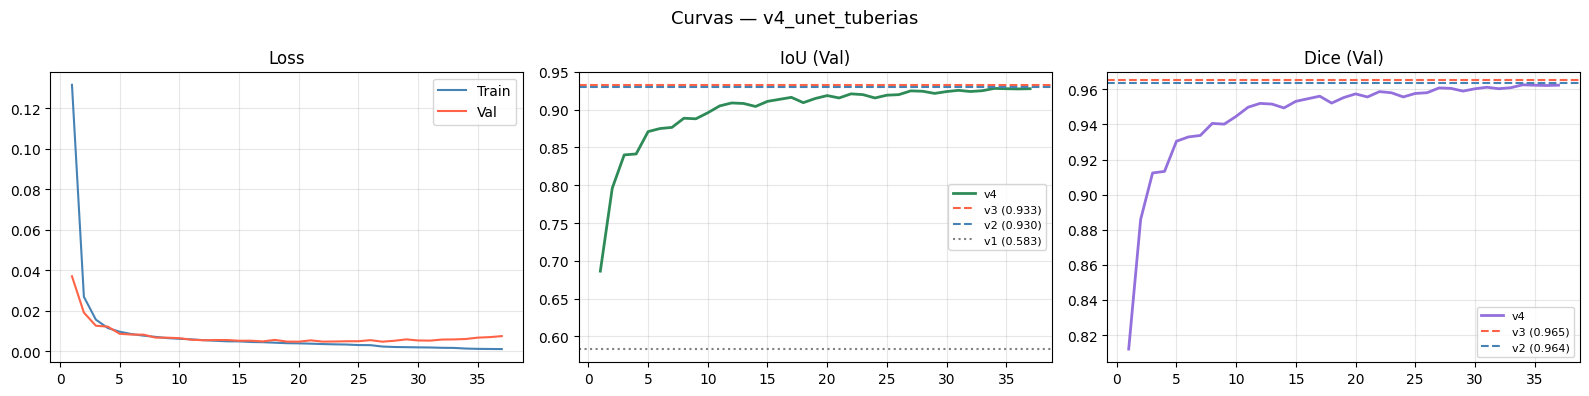

💾 Curvas guardadas en logs/


In [11]:
def graficar_curvas_v4(historial, config):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Curvas — {config["version"]}', fontsize=13)
    epochs = range(1, len(historial['train_loss']) + 1)

    axes[0].plot(epochs, historial['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs, historial['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, historial['val_iou'], color='seagreen', label='v4', linewidth=2)
    axes[1].axhline(y=V3_TEST_IOU, color='tomato',    linestyle='--', label=f'v3 ({V3_TEST_IOU:.3f})')
    axes[1].axhline(y=V2_TEST_IOU, color='steelblue', linestyle='--', label=f'v2 ({V2_TEST_IOU:.3f})')
    axes[1].axhline(y=V1_TEST_IOU, color='gray',      linestyle=':', label=f'v1 ({V1_TEST_IOU:.3f})')
    axes[1].set_title('IoU (Val)'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, historial['val_dice'], color='mediumpurple', label='v4', linewidth=2)
    axes[2].axhline(y=V3_TEST_DICE, color='tomato',    linestyle='--', label=f'v3 ({V3_TEST_DICE:.3f})')
    axes[2].axhline(y=V2_TEST_DICE, color='steelblue', linestyle='--', label=f'v2 ({V2_TEST_DICE:.3f})')
    axes[2].set_title('Dice (Val)'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH_LOGS, f"{config['version']}_curvas.png"), dpi=100)
    plt.show()
    print("💾 Curvas guardadas en logs/")

graficar_curvas_v4(historial, CONFIG)

In [12]:
modelo.load_state_dict(
    torch.load(os.path.join(PATH_MODELOS,
               f"{CONFIG['version']}_best_iou.pth"))
)
modelo.eval()

def evaluar_dataset(loader, nombre):
    iou_total = dice_total = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = modelo(imgs)
            iou_total  += calcular_iou(preds, masks)
            dice_total += calcular_dice(preds, masks)
    n = len(loader)
    print(f"   {nombre:<28} IoU: {iou_total/n:.4f} | Dice: {dice_total/n:.4f}")
    return iou_total/n, dice_total/n

kw = dict(batch_size=BATCH_SIZE, shuffle=False)
loaders = {
    'F1 Geometría Básica'    : DataLoader(test_f1_basica,   **kw),
    'F1 Ruido'               : DataLoader(test_f1_ruido,    **kw),
    'F2 Geometría Compleja'  : DataLoader(test_f2_compleja, **kw),
    'F2 Ruido Complejo'      : DataLoader(test_f2_ruido,    **kw),
    'F3 Tuberías Sintéticas' : DataLoader(test_f3_tuberias, **kw),
    'F3 Tuberías con Ruido'  : DataLoader(test_f3_ruido,    **kw),
}

print("=" * 62)
print("📊 EVALUACIÓN FINAL EN TEST — v4 desglosada")
print("=" * 62)

resultados_test = {}
for nombre, loader in loaders.items():
    iou, dice = evaluar_dataset(loader, nombre)
    resultados_test[nombre] = {'iou': iou, 'dice': dice}

iou_global  = sum(v['iou']  for v in resultados_test.values()) / len(resultados_test)
dice_global = sum(v['dice'] for v in resultados_test.values()) / len(resultados_test)
iou_f3  = (resultados_test['F3 Tuberías Sintéticas']['iou'] +
           resultados_test['F3 Tuberías con Ruido']['iou']) / 2
dice_f3 = (resultados_test['F3 Tuberías Sintéticas']['dice'] +
           resultados_test['F3 Tuberías con Ruido']['dice']) / 2

print("-" * 62)
print(f"   {'GLOBAL':<28} IoU: {iou_global:.4f} | Dice: {dice_global:.4f}")
print(f"\n   🎯 F3 Tuberías IoU  : {iou_f3:.4f}")
print(f"   🎯 F3 Tuberías Dice : {dice_f3:.4f}")
print(f"\n   Mejora vs v3 IoU  : {'+' if iou_global > V3_TEST_IOU else ''}{iou_global - V3_TEST_IOU:.4f}")
print("=" * 62)

📊 EVALUACIÓN FINAL EN TEST — v4 desglosada
   F1 Geometría Básica          IoU: 0.9372 | Dice: 0.9675
   F1 Ruido                     IoU: 0.9219 | Dice: 0.9593
   F2 Geometría Compleja        IoU: 0.9511 | Dice: 0.9749
   F2 Ruido Complejo            IoU: 0.9159 | Dice: 0.9560
   F3 Tuberías Sintéticas       IoU: 0.9296 | Dice: 0.9634
   F3 Tuberías con Ruido        IoU: 0.9259 | Dice: 0.9614
--------------------------------------------------------------
   GLOBAL                       IoU: 0.9303 | Dice: 0.9637

   🎯 F3 Tuberías IoU  : 0.9277
   🎯 F3 Tuberías Dice : 0.9624

   Mejora vs v3 IoU  : -0.0026


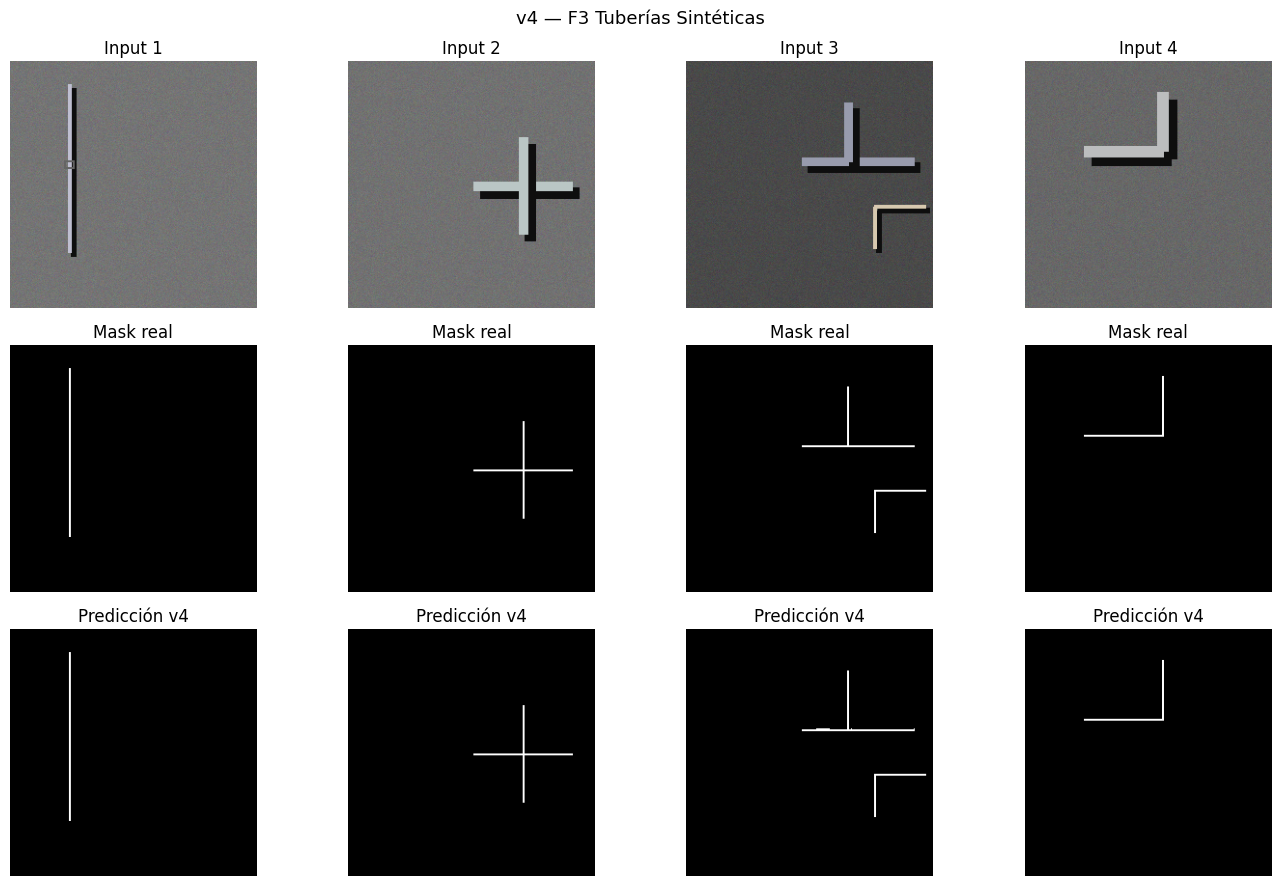

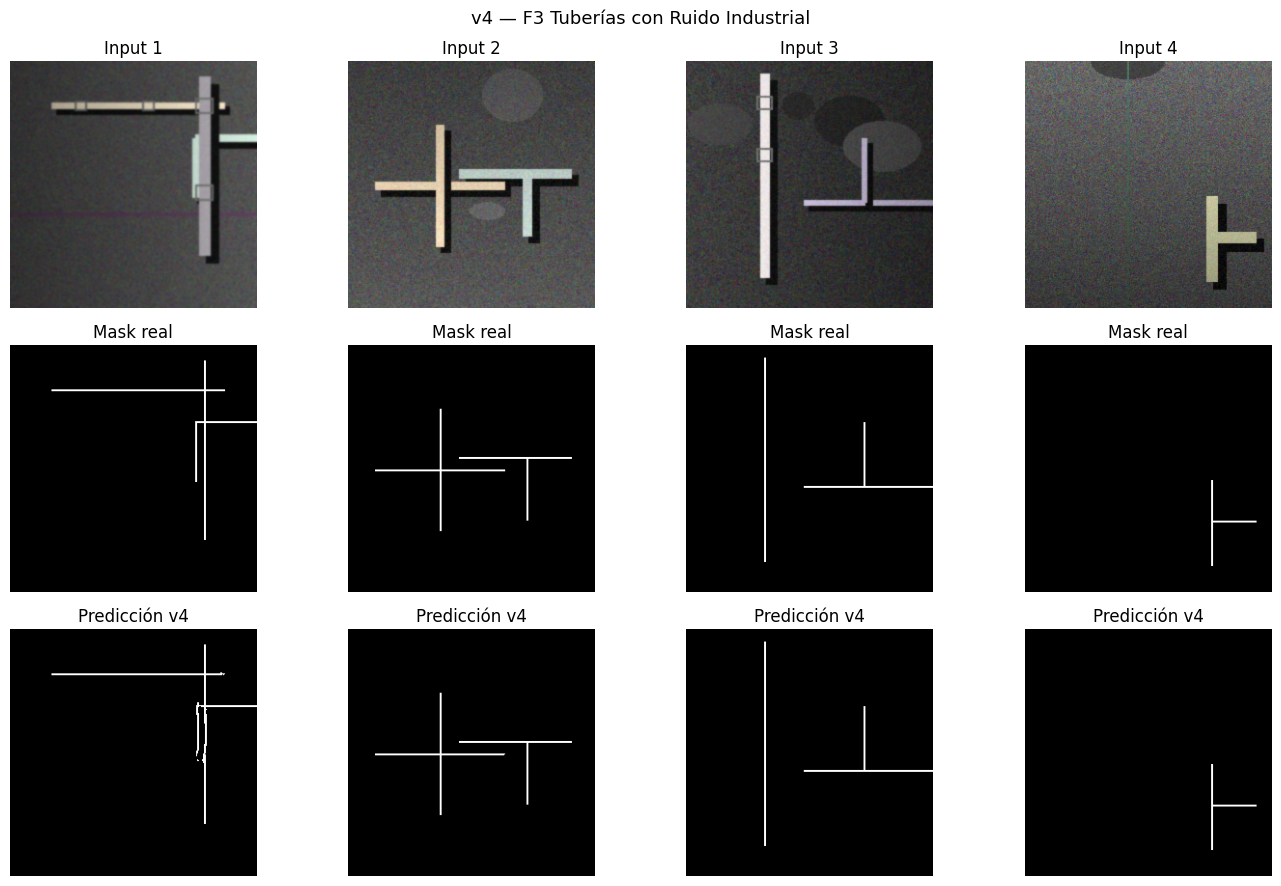

In [13]:
def visualizar_predicciones(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(titulo, fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred     = modelo(img_tensor.unsqueeze(0).to(device)).squeeze().cpu().numpy()
            img_np   = (img_tensor.permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)
            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)

            axes[0][col].imshow(img_np);               axes[0][col].set_title(f'Input {col+1}');  axes[0][col].axis('off')
            axes[1][col].imshow(mask_np,  cmap='gray'); axes[1][col].set_title('Mask real');       axes[1][col].axis('off')
            axes[2][col].imshow(pred_bin, cmap='gray'); axes[2][col].set_title('Predicción v4'); axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

visualizar_predicciones(modelo, test_f3_tuberias, 'v4 — F3 Tuberías Sintéticas')
visualizar_predicciones(modelo, test_f3_ruido,    'v4 — F3 Tuberías con Ruido Industrial')

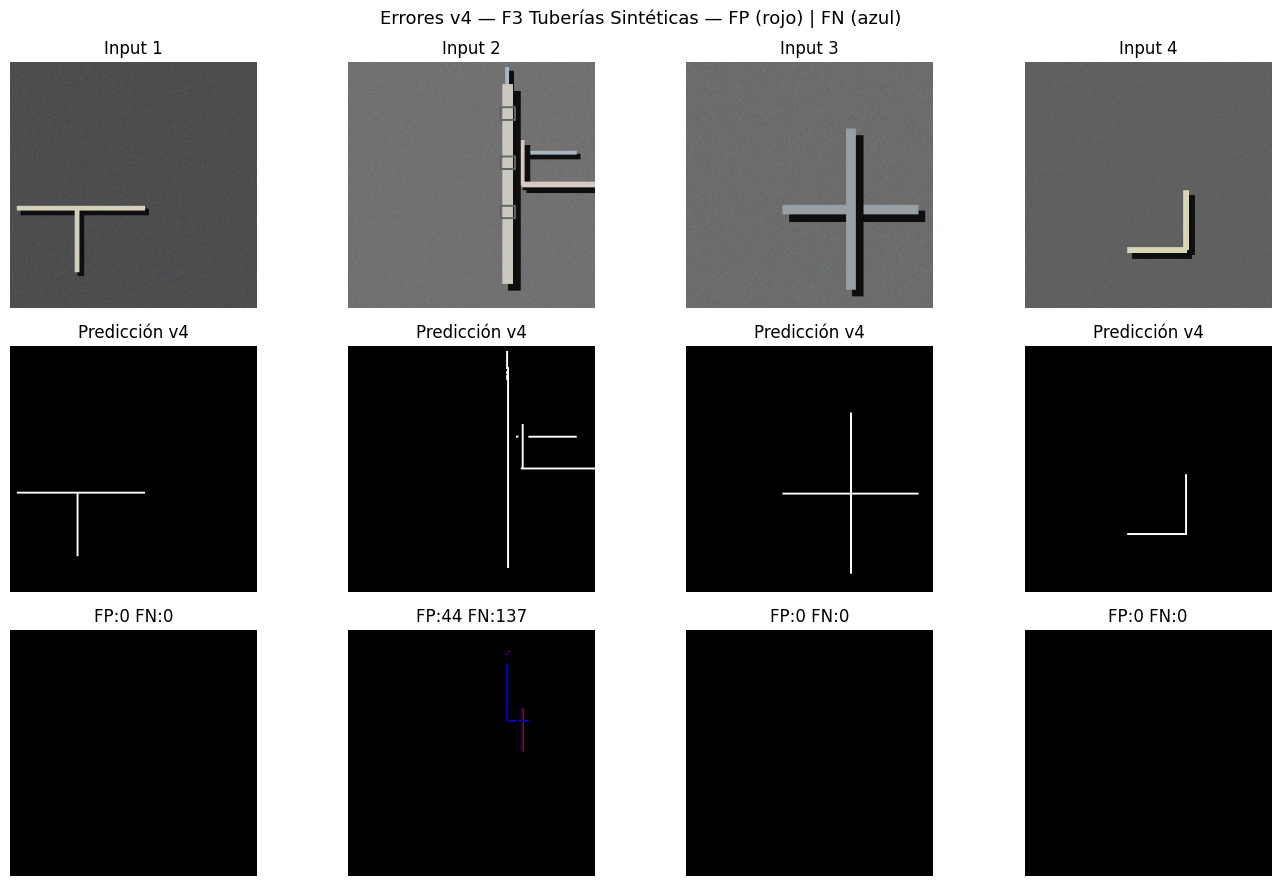

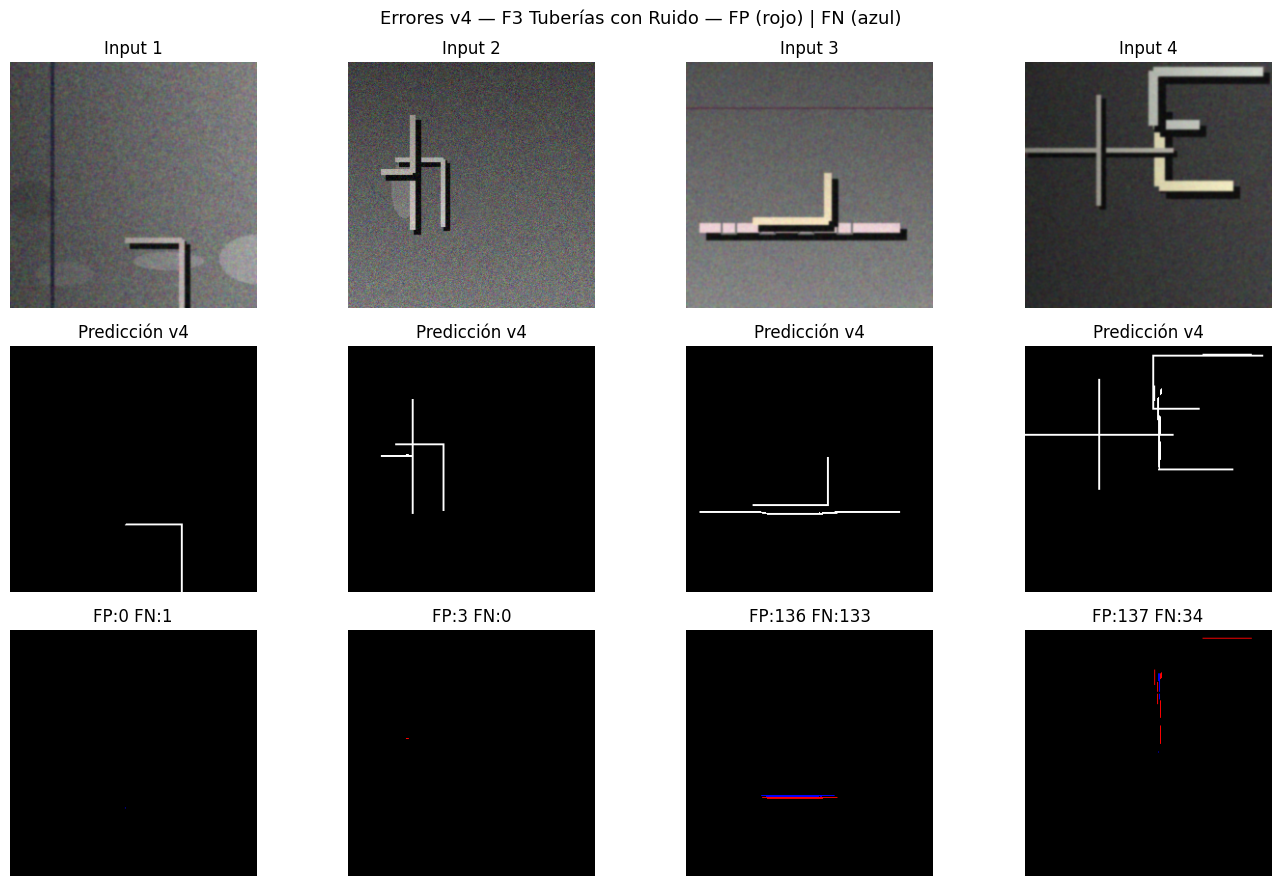

In [14]:
def analizar_errores(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(f'{titulo} — FP (rojo) | FN (azul)', fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred     = modelo(img_tensor.unsqueeze(0).to(device)).squeeze().cpu().numpy()
            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)
            gt_bin   = (mask_np > 0.5).astype(np.float32)
            fp = ((pred_bin==1) & (gt_bin==0)).astype(np.float32)
            fn = ((pred_bin==0) & (gt_bin==1)).astype(np.float32)
            error_img = np.zeros((*gt_bin.shape, 3))
            error_img[:,:,0] = fp
            error_img[:,:,2] = fn
            img_np = (img_tensor.permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)

            axes[0][col].imshow(img_np);    axes[0][col].set_title(f'Input {col+1}');          axes[0][col].axis('off')
            axes[1][col].imshow(pred_bin, cmap='gray'); axes[1][col].set_title('Predicción v4'); axes[1][col].axis('off')
            axes[2][col].imshow(error_img); axes[2][col].set_title(f'FP:{int(fp.sum())} FN:{int(fn.sum())}'); axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

analizar_errores(modelo, test_f3_tuberias, 'Errores v4 — F3 Tuberías Sintéticas')
analizar_errores(modelo, test_f3_ruido,    'Errores v4 — F3 Tuberías con Ruido')

In [15]:
print("=" * 65)
print("📋 COMPARATIVA COMPLETA DE VERSIONES")
print("=" * 65)
print(f"{'Modelo':<24} {'IoU':>10} {'Dice':>10} {'Dataset':>14}")
print("-" * 62)
print(f"{'Baseline Canny':<24} {BASELINE_IOU:>10.4f} {'—':>10} {'—':>14}")
print(f"{'v1 CNN':<24} {V1_TEST_IOU:>10.4f} {V1_TEST_DICE:>10.4f} {'F1':>14}")
print(f"{'v2 U-Net':<24} {V2_TEST_IOU:>10.4f} {V2_TEST_DICE:>10.4f} {'F1':>14}")
print(f"{'v3 U-Net acum.':<24} {V3_TEST_IOU:>10.4f} {V3_TEST_DICE:>10.4f} {'F1+F2':>14}")
print(f"{'v4 U-Net acum.':<24} {iou_global:>10.4f} {dice_global:>10.4f} {'F1+F2+F3':>14}")
print("=" * 65)
print(f"\n   🎯 F3 Tuberías IoU  : {iou_f3:.4f}")
print(f"   🎯 F3 Tuberías Dice : {dice_f3:.4f}")

comparativa = {
    'baseline': {'iou': BASELINE_IOU},
    'v1_cnn'  : {'iou': V1_TEST_IOU,  'dice': V1_TEST_DICE},
    'v2_unet' : {'iou': V2_TEST_IOU,  'dice': V2_TEST_DICE},
    'v3_unet' : {'iou': V3_TEST_IOU,  'dice': V3_TEST_DICE},
    'v4_unet' : {'iou': iou_global,   'dice': dice_global,
                 'f3_iou': iou_f3,    'f3_dice': dice_f3},
    'detalle_v4': resultados_test
}
with open(os.path.join(PATH_LOGS, 'comparativa_versiones.json'), 'w') as f:
    json.dump(comparativa, f, indent=4)
print(f"\n💾 Comparativa guardada en logs/")

📋 COMPARATIVA COMPLETA DE VERSIONES
Modelo                          IoU       Dice        Dataset
--------------------------------------------------------------
Baseline Canny               0.0555          —              —
v1 CNN                       0.5833     0.7363             F1
v2 U-Net                     0.9299     0.9635             F1
v3 U-Net acum.               0.9329     0.9651          F1+F2
v4 U-Net acum.               0.9303     0.9637       F1+F2+F3

   🎯 F3 Tuberías IoU  : 0.9277
   🎯 F3 Tuberías Dice : 0.9624

💾 Comparativa guardada en logs/


In [16]:
def inferencia(ruta_imagen, modelo, threshold=0.5, img_size=256):
    modelo.eval()
    img = Image.open(ruta_imagen).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = modelo(img_tensor).squeeze().cpu().numpy()

    pred_bin = (pred > threshold).astype(np.float32)
    img_np   = np.array(img.resize((img_size, img_size))) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('Inferencia as_built — v4 U-Net Tuberías', fontsize=13)
    axes[0].imshow(img_np);               axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(pred_bin, cmap='gray'); axes[1].set_title('Overlay');   axes[1].axis('off')
    overlay = img_np.copy()
    overlay[pred_bin == 1] = [0, 1, 0]
    axes[2].imshow(overlay); axes[2].set_title('Superpuesto'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()
    return pred_bin

# resultado = inferencia(
#     '/content/drive/MyDrive/trazos/imagenes_de_ejemplo/Estanteria.png',
#     modelo
# )
print("✅ Función de inferencia lista")

✅ Función de inferencia lista


In [17]:
resumen_version = f"""
=======================================================
RESUMEN — as_built | {CONFIG['version']}
=======================================================

CAMBIO PRINCIPAL vs versiones anteriores:
- Dataset leído desde RAM local en vez de Drive
- Eliminó espera de 3 horas en primera época
- NUM_WORKERS=4 + pin_memory=True
- Dataset: F1+F2+F3 acumulativo (6000 train)

RESULTADOS GLOBALES:
- Baseline Canny : {BASELINE_IOU:.4f}
- v1 CNN         : {V1_TEST_IOU:.4f}
- v2 U-Net       : {V2_TEST_IOU:.4f}
- v3 U-Net       : {V3_TEST_IOU:.4f}
- v4 U-Net       : {iou_global:.4f}
- Mejora v3→v4   : {'+' if iou_global > V3_TEST_IOU else ''}{iou_global - V3_TEST_IOU:.4f}

F3 TUBERÍAS:
- IoU  : {iou_f3:.4f}
- Dice : {dice_f3:.4f}

DESGLOSE:
""" + '\n'.join([
    f"- {k:<28}: IoU {v['iou']:.4f} | Dice {v['dice']:.4f}"
    for k, v in resultados_test.items()
]) + f"""

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

PRÓXIMA FASE:
- Si F3 IoU > 0.85 → avanzar a dataset real
- Si F3 IoU < 0.80 → más datos de tuberías
=======================================================
"""

print(resumen_version)
with open(os.path.join(PATH_LOGS, f"{CONFIG['version']}_notas.txt"), 'w') as f:
    f.write(resumen_version)
print("💾 Notas guardadas en logs/")


RESUMEN — as_built | v4_unet_tuberias

CAMBIO PRINCIPAL vs versiones anteriores:
- Dataset leído desde RAM local en vez de Drive
- Eliminó espera de 3 horas en primera época
- NUM_WORKERS=4 + pin_memory=True
- Dataset: F1+F2+F3 acumulativo (6000 train)

RESULTADOS GLOBALES:
- Baseline Canny : 0.0555
- v1 CNN         : 0.5833
- v2 U-Net       : 0.9299
- v3 U-Net       : 0.9329
- v4 U-Net       : 0.9303
- Mejora v3→v4   : -0.0026

F3 TUBERÍAS:
- IoU  : 0.9277
- Dice : 0.9624

DESGLOSE:
- F1 Geometría Básica         : IoU 0.9372 | Dice 0.9675
- F1 Ruido                    : IoU 0.9219 | Dice 0.9593
- F2 Geometría Compleja       : IoU 0.9511 | Dice 0.9749
- F2 Ruido Complejo           : IoU 0.9159 | Dice 0.9560
- F3 Tuberías Sintéticas      : IoU 0.9296 | Dice 0.9634
- F3 Tuberías con Ruido       : IoU 0.9259 | Dice 0.9614

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

PRÓXIMA FASE:
- Si F3 IoU > 0.85 → avanzar a dataset r